<a href="https://colab.research.google.com/github/ofredrickson/music_trends/blob/main/datascience_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd

df = pd.read_csv('spotifysongs.csv')
df.head()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
0,0gNNToCW3qjabgTyBSjt3H,!Que Vida! - Mono Version,['Love'],220560,11/1/66,1966,0.5250,0.600,0.540,0.00305,0.100,-11.803,0.0328,125.898,0.547,1,9,26,0
1,0tMgFpOrXZR6irEOLNWwJL,"""40""",['U2'],157840,2/28/83,1983,0.2280,0.368,0.480,0.70700,0.159,-11.605,0.0306,150.166,0.338,1,8,21,0
2,2ZywW3VyVx6rrlrX75n3JB,"""40"" - Live",['U2'],226200,8/20/83,1983,0.0998,0.272,0.684,0.01450,0.946,-9.728,0.0505,143.079,0.279,1,8,41,0
3,6DdWA7D1o5TU2kXWyCLcch,"""40"" - Remastered 2008",['U2'],157667,2/28/83,1983,0.1850,0.371,0.545,0.58200,0.183,-9.315,0.0307,150.316,0.310,1,8,37,0
4,3vMmwsAiLDCfyc1jl76lQE,"""40"" - Remastered 2008",['U2'],157667,2/28/83,1983,0.1850,0.371,0.545,0.58200,0.183,-9.315,0.0307,150.316,0.310,1,8,35,0


In [67]:
# #show songs with popularity 90 or higher
# popular_songs = df[df['popularity'] >= 90]

# #display selected columns
# popular_songs[
#     ['name', 'artists', 'year', 'popularity']
# ].sort_values(by='popularity', ascending=False)

#show songs with popularity between 60 and 80
mid_popular_songs = df[
    (df['popularity'] >= 42) & (df['popularity'] <= 43)
]

#display selected columns
mid_popular_songs[
    ['name', 'artists', 'year', 'popularity']
].sort_values(by='popularity', ascending=False)


,name,artists,year,popularity
168946,似水流年,['Anita Mui'],1987,43
168944,伊斯坦堡,['Jay Chou'],2000,43
168920,中央フリーウェイ,['Yumi Arai'],1976,43
168692,אדם בתוך עצמו,['Shalom Hanoch'],1977,43
168687,Что такое осень,['DDT'],1992,43
...,...,...,...,...
100,'65 Love Affair,['Paul Davis'],1979,42
99,'57 Chevrolet,['Billie Jo Spears'],1987,42
70,"#41 - Live at Luther College, Decorah, IA - Fe...","['Dave Matthews', 'Tim Reynolds']",1999,42
58,#1,['Aphex Twin'],1994,42


In [68]:
#categorize time periods (blog era vs modern social media era)

df = df[df['year'] >= 2000]

df['era'] = df['year'].apply(lambda x: 'blog' if x <= 2012 else 'modern')
# df['era'] = df['year'].apply(
#     lambda x: 'blog' if 2000 <= x <= 2010 else ('modern' if 2015 <= x <= 2020 else None)
# )

In [69]:
#define mainstream vs niche/alternative genres

df['category'] = df['popularity'].apply(
    lambda x: 'mainstream' if x >= 70 else 'niche'
)

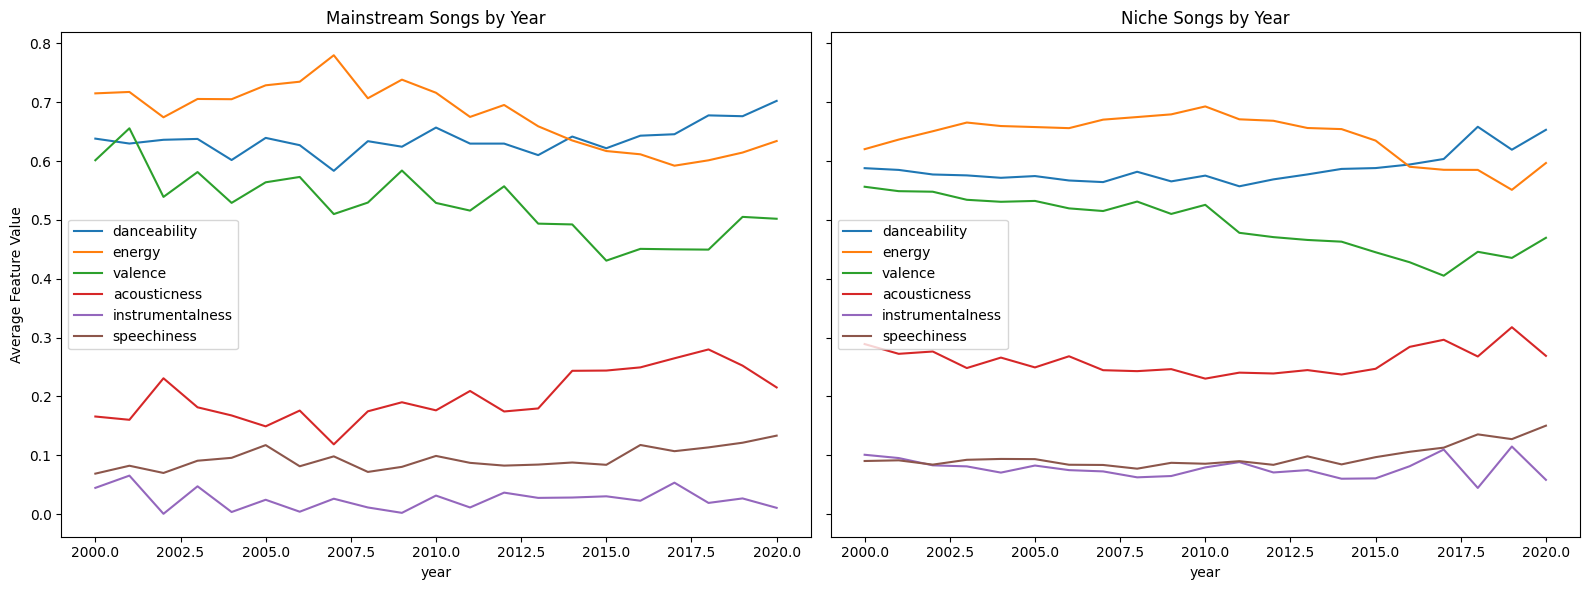

In [70]:
#compare audio features over time (2000-2020)
features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness']

# df.groupby('year')[features].mean().plot()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, cat in zip(axes, ['mainstream', 'niche']):
    (
        df[df['category'] == cat]
        .groupby('year')[features]
        .mean()
        .plot(ax=ax)
    )

    ax.set_title(f'{cat.title()} Songs by Year')
    ax.set_ylabel('Average Feature Value')

plt.tight_layout()
plt.show()

In [71]:
#compare features of eras and popularity
df.groupby('era')[features].mean()
df.groupby(['era', 'category'])[features].mean()

danceability    energy   valence  acousticness  \
era    category                                                     
blog   mainstream      0.629336  0.712328  0.554222      0.176162   
       niche           0.573364  0.661870  0.523409      0.254992   
modern mainstream      0.670632  0.615101  0.477838      0.248713   
       niche           0.605022  0.612472  0.444897      0.267264   

                   instrumentalness  speechiness  
era    category                                   
blog   mainstream          0.023075     0.086639  
       niche               0.078988     0.087449  
modern mainstream          0.024946     0.116356  
       niche               0.074968     0.109953

In [72]:
#statistical difference testing

from scipy.stats import ttest_ind, mannwhitneyu

#extract feature array
blog_era_vals = df[df['era'] == 'blog']['energy']
modern_era_vals = df[df['era'] == 'modern']['energy']

#t-testing
t_stat, p_val_t = ttest_ind(blog_era_vals, modern_era_vals, equal_var=False)

#mann-whitney
u_stat, p_val_u = mannwhitneyu(blog_era_vals, modern_era_vals)

print("t-test p-value:", p_val_t)
print("Mann-Whitney p-value:", p_val_u)

t-test p-value: 2.01420748395405e-111
Mann-Whitney p-value: 1.5133312361955777e-153


In [73]:
import numpy as np
import pandas as pd

features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'tempo', 'loudness']

results = []

def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.var(x) + np.var(y)) / 2)


#loop over all features in statistical analysis
for feature in features:
    blog_vals = df[df['era'] == 'blog'][feature]
    modern_vals = df[df['era'] == 'modern'][feature]

    #drop missing values
    blog_vals = blog_vals.dropna()
    modern_vals = modern_vals.dropna()

    t_stat, p_t = ttest_ind(blog_vals, modern_vals, equal_var=False)
    u_stat, p_u = mannwhitneyu(blog_vals, modern_vals)
    d = cohens_d(blog_vals, modern_vals)

    results.append({
        'feature': feature,
        'p_ttest': p_t,
        'p_mannwhitney': p_u,
        'cohens_d': d
    })

results_df = pd.DataFrame(results)
print(results_df)

            feature        p_ttest  p_mannwhitney  cohens_d
0      danceability  2.196524e-138  8.874497e-160 -0.254556
1            energy  2.014207e-111  1.513331e-153  0.225592
2           valence  2.195407e-189  2.466325e-174  0.295830
3      acousticness   4.002094e-04   1.478444e-33 -0.035710
4  instrumentalness   3.932767e-09   6.053536e-77  0.059205
5       speechiness  4.934318e-105  3.252060e-175 -0.225107
6             tempo   8.911986e-07   5.765245e-03  0.049726
7          loudness   5.089548e-08   1.773212e-13  0.055785


**What These Results Mean**

Statistical testing revealed significant differences across all examined audio features (p < 0.001). However, effect size analysis using Cohen’s d indicates that most differences are small in magnitude. Valence (d = 0.296) and danceability (d = -0.255) exhibit the largest shifts, suggesting modest changes in emotional tone and rhythmic structure between eras. In contrast, instrumentalness (d = 0.059) and acousticness (d = -0.036) show negligible differences, highlighting the importance of distinguishing statistical significance from practical significance in large datasets.

In [74]:
#machine learning model 1 — logistic regression
#ponders the question: “Can we distinguish blog-era vs modern music based on sound alone?”

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#---------- STEP 1: define features + target ------------------
features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'tempo', 'loudness']
X = df[features]

#convert eras into numeric labels
# blog era (2000–2012) = 0
# modern era (2013–2020) = 1

df['era_label'] = df['era'].map({
    'blog': 0,
    'modern': 1
})

y = df['era_label']

#---------- STEP 2: train/test split ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#----------- STEP 3: scale the features ------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#----------- STEP 4: train logistic regression -------------------

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
log_model.fit(X_train_scaled, y_train)

#------------ STEP 5: make predictions ---------------------------

y_pred = log_model.predict(X_test_scaled)

#------------- STEP 6: evaluate model + print results ---------------

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6073

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.62      0.66      5200
           1       0.48      0.58      0.53      3132

    accuracy                           0.61      8332
   macro avg       0.60      0.60      0.60      8332
weighted avg       0.63      0.61      0.61      8332


Confusion Matrix:

[[3242 1958]
 [1314 1818]]


In [75]:
#machine learning model 2 – random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.7138

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.88      0.79      5200
           1       0.69      0.44      0.54      3132

    accuracy                           0.71      8332
   macro avg       0.70      0.66      0.66      8332
weighted avg       0.71      0.71      0.70      8332


Confusion Matrix:

[[4574  626]
 [1759 1373]]


            feature  importance
2           valence    0.148914
5       speechiness    0.138530
1            energy    0.134995
0      danceability    0.131124
7          loudness    0.127275
3      acousticness    0.122677
6             tempo    0.121823
4  instrumentalness    0.074663


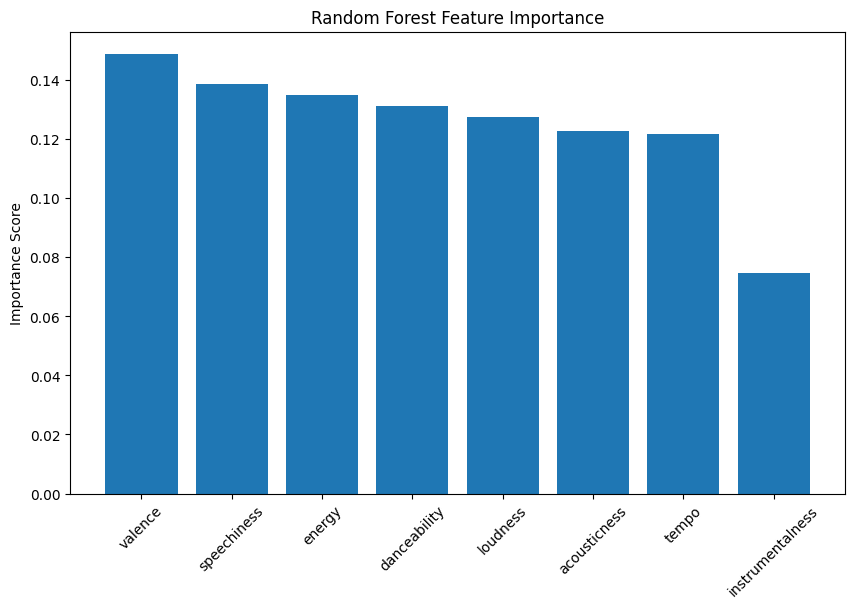

In [76]:
#plotting feature importance

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df)

#plot feature importance
plt.figure(figsize=(10,6))
plt.bar(
    importance_df['feature'],
    importance_df['importance']
)

plt.xticks(rotation=45)
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance Score')
plt.show()

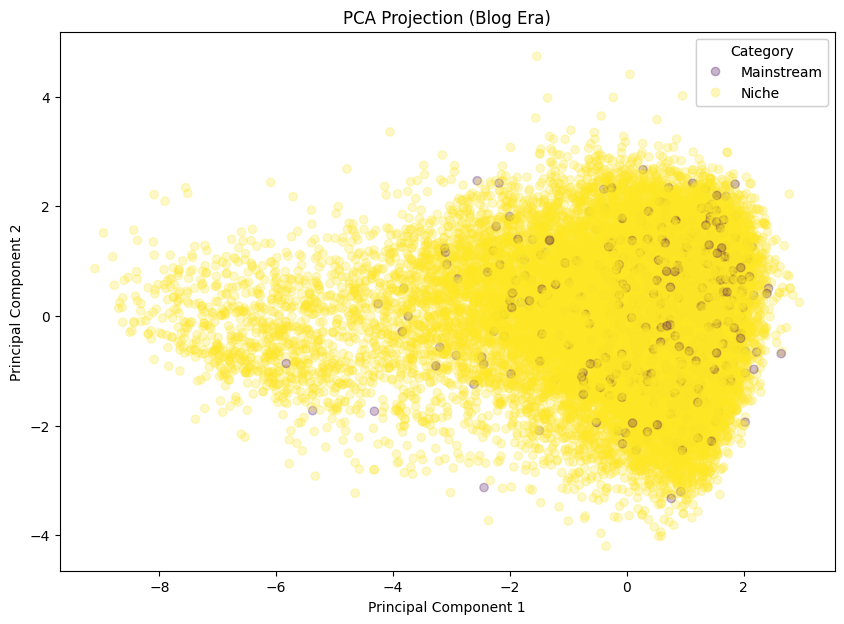

Blog Era Explained Variance Ratio:
[0.38128337 0.18085192]




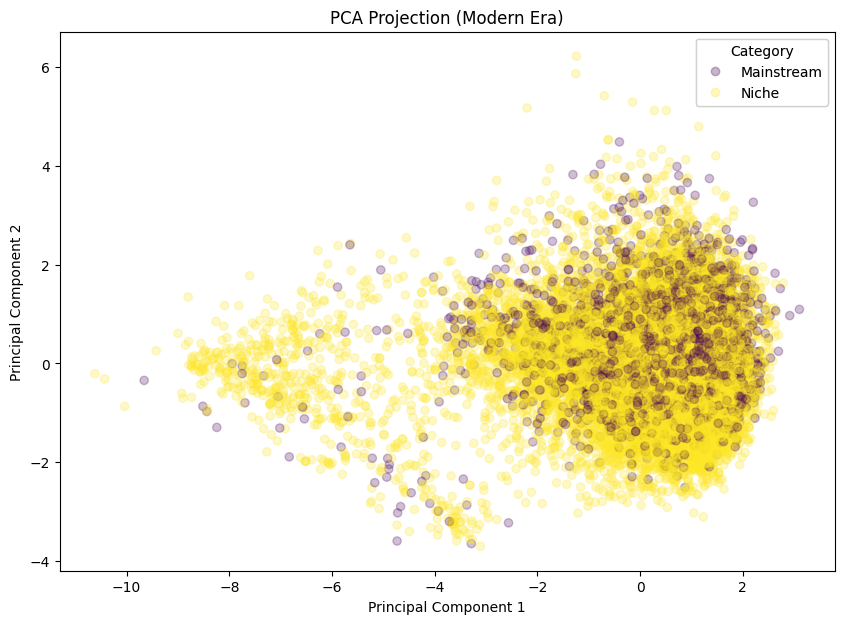

Modern Era Explained Variance Ratio:
[0.3949284  0.15211394]




In [77]:
#PCA visualization
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for era_name in ['blog', 'modern']:

    #filter dataframe
    era_df = df[df['era'] == era_name]

    X = era_df[features]

    #scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    #run PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    #convert categories to numeric
    category_map = {
        'mainstream': 0,
        'niche': 1
    }

    category_labels = era_df['category'].map(category_map)

    #plot
    plt.figure(figsize=(10,7))

    scatter = plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=category_labels,
        cmap='viridis',
        alpha=0.25
    )

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')

    plt.title(f'PCA Projection ({era_name.capitalize()} Era)')

    #legend
    legend1 = plt.legend(
        *scatter.legend_elements(),
        title="Category"
    )

    legend_labels = ['Mainstream', 'Niche']

    for text, label in zip(legend1.get_texts(), legend_labels):
        text.set_text(label)

    plt.gca().add_artist(legend1)

    plt.show()

    #print explained variance
    print(f"{era_name.capitalize()} Era Explained Variance Ratio:")
    print(pca.explained_variance_ratio_)
    print("\n")

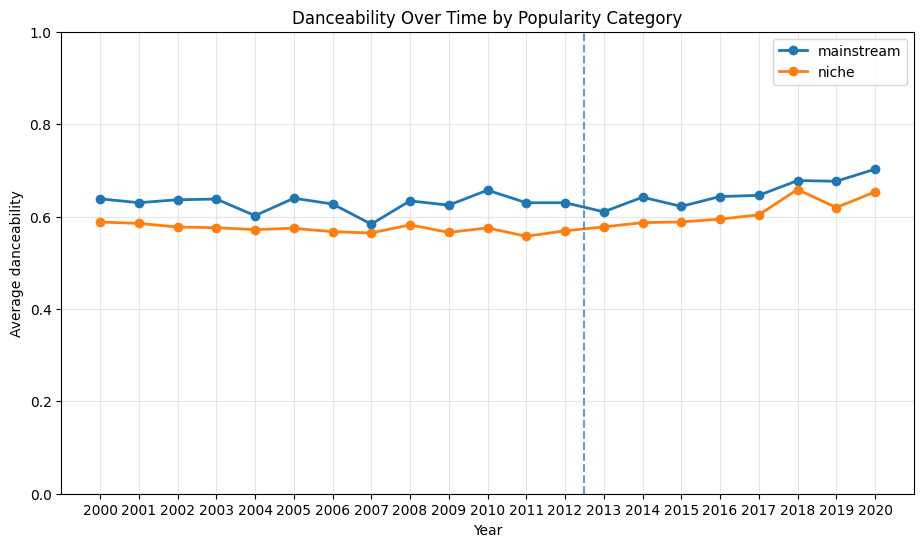

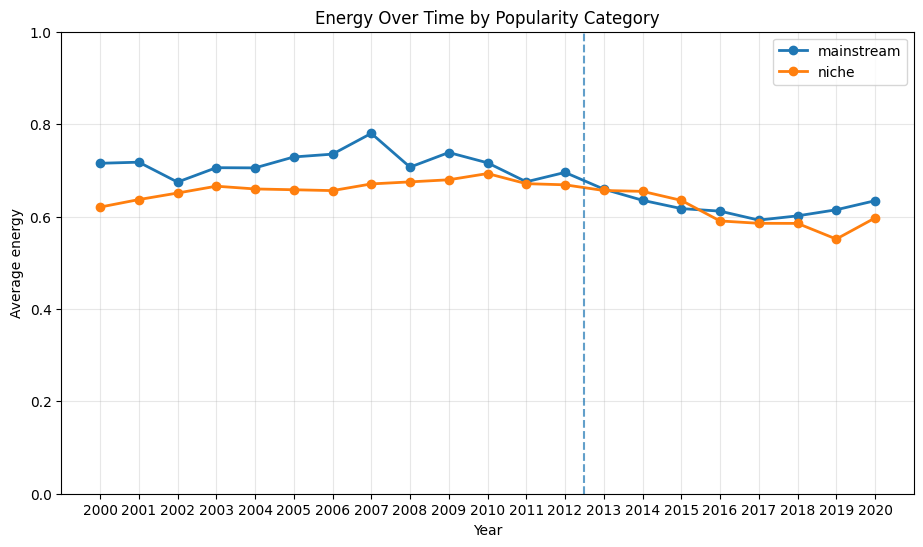

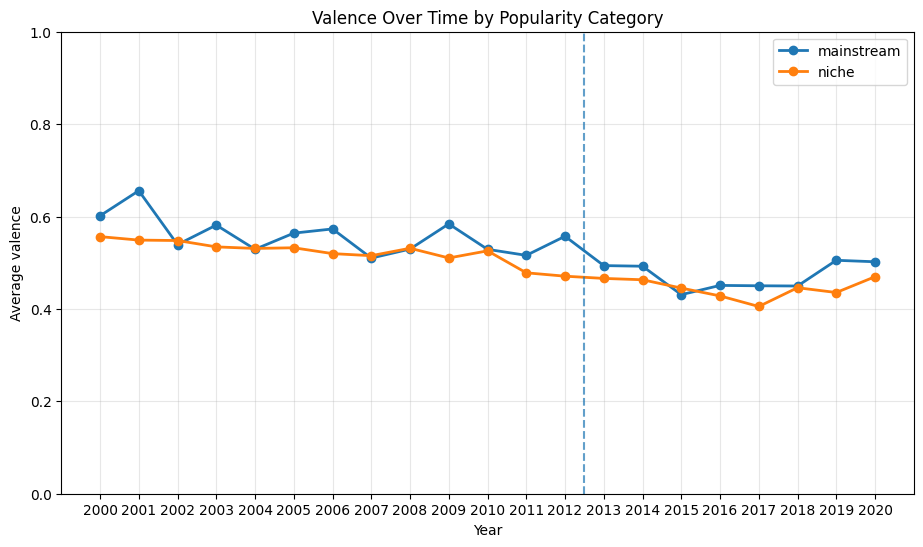

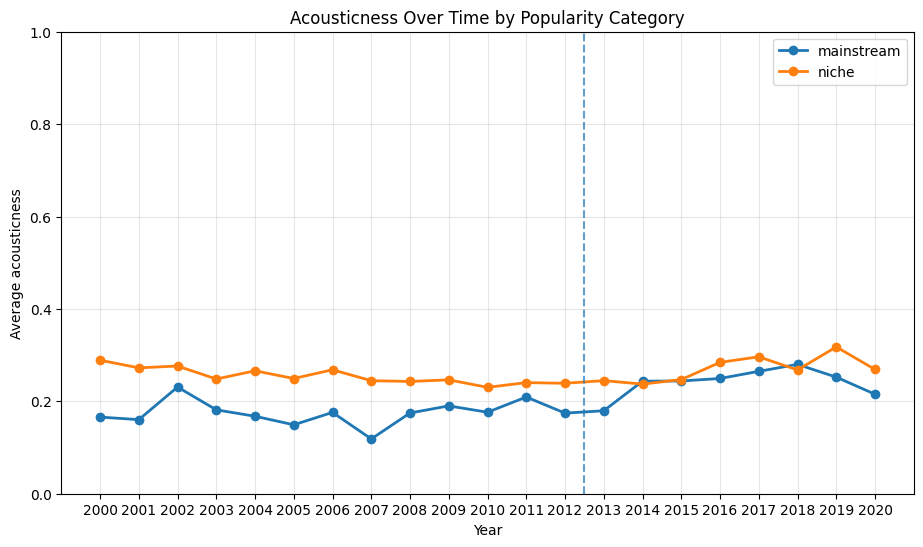

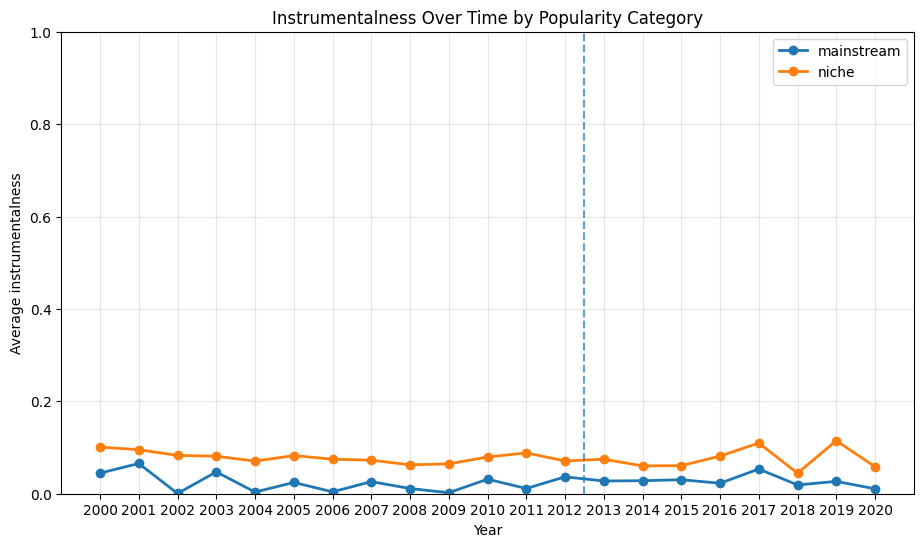

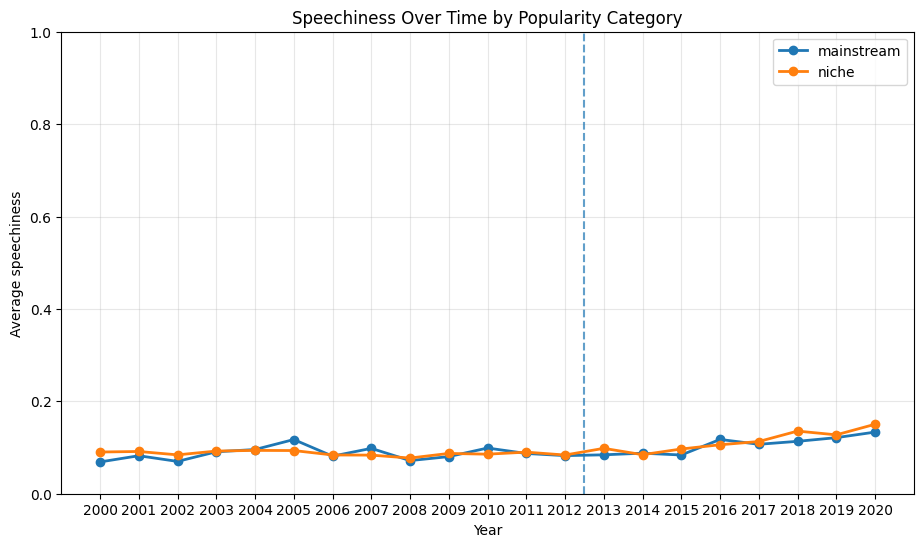

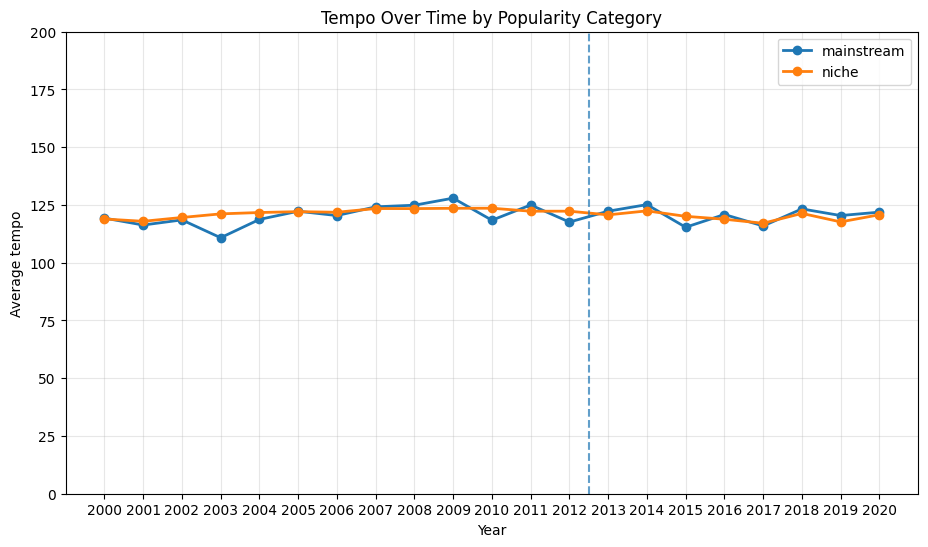

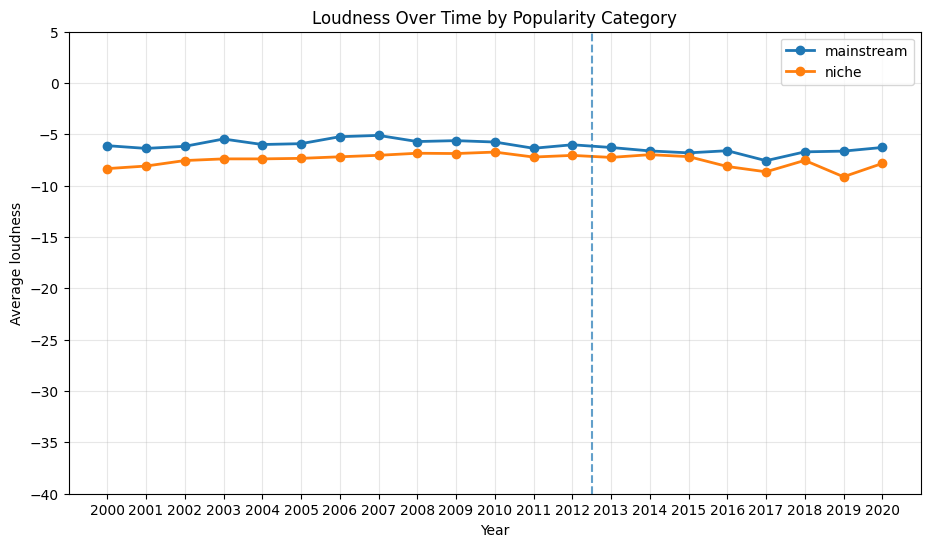

In [78]:
#visualize temporal trends for each year across mainstream & niche music categories

#create yearly averages
yearly_category_trends = (
    df.groupby(['year', 'category'])[features]
    .mean()
    .reset_index()
)

#plot each feature over time

for feature in features:
    plt.figure(figsize=(11,6))

    for category in ['mainstream', 'niche']:

        subset = yearly_category_trends[
            yearly_category_trends['category'] == category
        ]

        plt.plot(
            subset['year'],
            subset[feature],
            marker='o',
            linewidth=2,
            label=category
        )

    #add vertical divider between eras
    plt.axvline(
        x=2012.5,
        linestyle='--',
        alpha=0.7
    )


    if feature == 'tempo':
        plt.ylim(0, 200)
    elif feature == 'loudness':
        plt.ylim(-40, 5)
    else:
        plt.ylim(0, 1)


    plt.title(f'{feature.capitalize()} Over Time by Popularity Category')
    plt.xlabel('Year')
    plt.ylabel(f'Average {feature}')

    plt.xticks(sorted(df['year'].unique()))
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


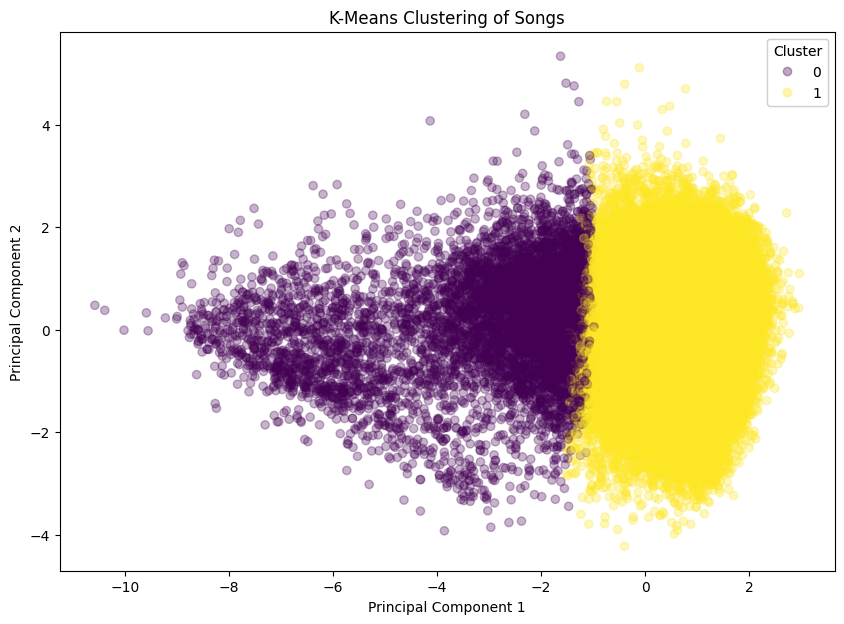

In [79]:
#K-means clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df[features].dropna()

#scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#run k-means
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

#add cluster labels to dataframe
df['cluster'] = clusters

#pca for visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#plot clusters
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0], #0 = blog
    X_pca[:,1], #1 = modern
    c=df['cluster'],
    cmap='viridis',
    alpha=0.3
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering of Songs')

legend1 = plt.legend(
    *scatter.legend_elements(),
    title="Cluster"
)

plt.gca().add_artist(legend1)

plt.show()

In [80]:
cluster_era_table = pd.crosstab(
    df['cluster'],
    df['era']
)

cluster_feature_means = df.groupby('cluster')[features].mean()

print(cluster_feature_means)
print("\n")
print(cluster_era_table)

         danceability    energy   valence  acousticness  instrumentalness  \
cluster                                                                     
0            0.452550  0.307908  0.270302      0.712333          0.283297   
1            0.620194  0.714587  0.544296      0.161778          0.028729   

         speechiness       tempo   loudness  
cluster                                      
0           0.053355  109.086494 -13.873558  
1           0.105386  123.586588  -6.006974  


era       blog  modern
cluster               
0         4465    2736
1        21535   12920


**Final Thoughts**

Although internet era shifts correspond to measurable differences in audio characteristics, these differences are subtle and highly overlapping. Supervised machine learning models can predict era above chance levels, suggesting that internet platform evolution influenced musical production trends. However, unsupervised clustering indicates that broader stylistic dimensions remain more dominant than historical era labels, implying that musical change occurred gradually rather than through sharply distinct transitions.